## Carregamento dos dados

In [1]:
import pandas as pd

df = pd.read_csv('/content/airquality_dataset.csv')

print(len(df))

# Check for missing values
print(df.isnull().sum())

# Check the amount of samples for each class
print('ON:', len(df[df['ac_status'] == 'ON']))
print('OFF:', len(df[df['ac_status'] == 'OFF']))

138847
timestamp                  0
temperature                0
humidity                   0
light_sensor_value         0
light_sensor_resistance    0
co2_value                  0
voc_value                  0
ac_status                  0
dtype: int64
ON: 48031
OFF: 90816


## Cálculo de medidas

In [2]:
import numpy as np

window_size = 100  # for calculation of mean rate of temperature change
time_threshold = 1.0  # in hours, for calculation of cumulative/aggregate variables

# Get the time difference between two samples
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%m/%Y %H:%M')
df['time_diff'] = df['timestamp'].diff()

# Count samples since last reset of status, also considerning gaps between days
# df['reset_condition'] = ((df['ac_status'].diff() != 0)
#                          | (df['time_diff'] > pd.Timedelta(hours=time_threshold)))
# df['reset_group'] = df['reset_condition'].cumsum()
# df['samples_since_reset'] = df.groupby('reset_group').cumcount()

# Calculate mean rates of temperature change
df['temp_diff'] = df['temperature'].diff()

for index, row in df.iterrows():
    # For the first entry of each day, default the difference to 0
    if row['time_diff'] > pd.Timedelta(hours=time_threshold) or index == 0:
        temp_diff_window = [0]
    else:
        # Add the current difference value to the window
        temp_diff_window.append(row['temp_diff'])
        # Remove the earliest difference value if the window size is excedeed
        if len(temp_diff_window) > window_size:
            temp_diff_window.pop(0)

    mean_temp_change = np.mean(temp_diff_window)
    df.at[index, 'mean_temp_change'] = mean_temp_change

## Exploração dos dados

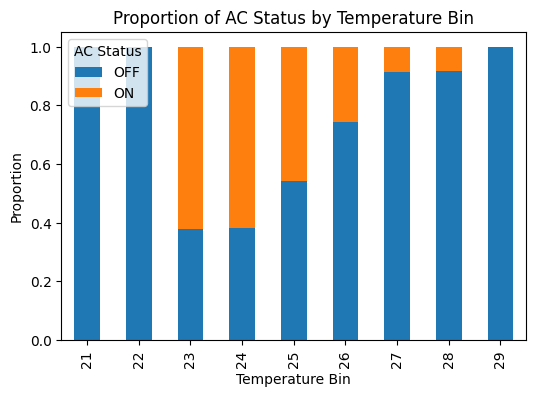

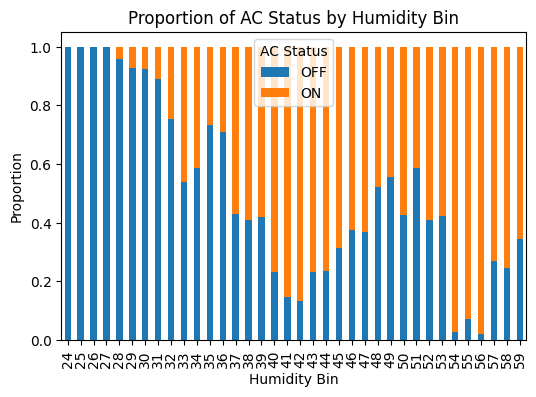

/tmp/ipython-input-3-1637376033.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ac_proportion = df.groupby(mean_temp_change_bins)['ac_status'].value_counts(normalize=True).unstack()


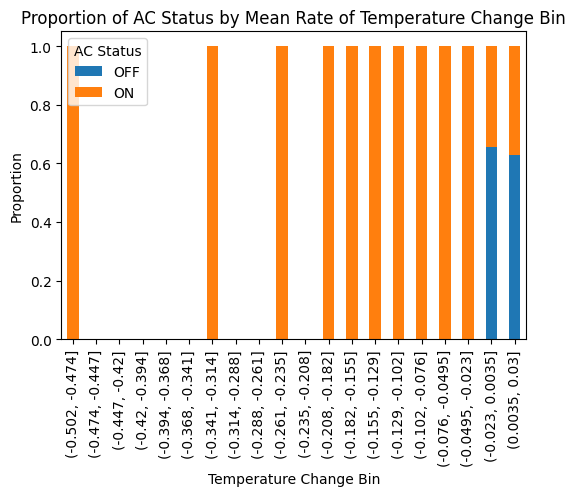

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the hour of the day
# hours = timestamp.dt.hour

# Plot the temperature by hour of the day
# plt.figure(figsize=(6, 4))
# sns.scatterplot(x=hours, y=df['temperature'])
# plt.title('Temperature by Hour Bin')
# plt.xlabel('Hour Bin')
# plt.ylabel('Temperature')
# plt.show()

# Plot the proportion of AC status by light sensor value
# lsv_bins = pd.cut(df['light_sensor_value'], bins=20)

# ac_proportion = df.groupby(lsv_bins)['ac_status'].value_counts(normalize=True).unstack()
# ac_proportion.plot(kind='bar', stacked=True, figsize=(6, 4))
# plt.title('Proportion of AC Status by Light Sensor Value')
# plt.xlabel('Light Sensor Value')
# plt.ylabel('Proportion')
# plt.legend(title='AC Status', labels=['OFF', 'ON'])
# plt.show()

# Plot the proportion of AC status by hour bin
# ac_proportion = df.groupby(hours)['ac_status'].value_counts(normalize=True).unstack()
# ac_proportion = ac_proportion.reindex(range(24), fill_value=0)  # reindex to include missing hours
# ac_proportion.plot(kind='bar', stacked=True, figsize=(6, 4))
# plt.title('Proportion of AC Status by Hour Bin')
# plt.xlabel('Hour Bin')
# plt.ylabel('Proportion')
# plt.legend(title='AC Status', labels=['OFF', 'ON'])
# plt.show()

# Plot the proportion of AC status by temperature bin
ac_proportion = df.groupby('temperature')['ac_status'].value_counts(normalize=True).unstack()
ac_proportion.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title('Proportion of AC Status by Temperature Bin')
plt.xlabel('Temperature Bin')
plt.ylabel('Proportion')
plt.legend(title='AC Status', labels=['OFF', 'ON'])
plt.show()

# Plot the proportion of AC status by humidity bin
ac_proportion = df.groupby('humidity')['ac_status'].value_counts(normalize=True).unstack()
ac_proportion.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title('Proportion of AC Status by Humidity Bin')
plt.xlabel('Humidity Bin')
plt.ylabel('Proportion')
plt.legend(title='AC Status', labels=['OFF', 'ON'])
plt.show()

# Plot the proportion of AC status by temperature change bin
mean_temp_change_bins = pd.cut(df['mean_temp_change'], bins=20, include_lowest=True)

ac_proportion = df.groupby(mean_temp_change_bins)['ac_status'].value_counts(normalize=True).unstack()
ac_proportion.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title('Proportion of AC Status by Mean Rate of Temperature Change Bin')
plt.xlabel('Temperature Change Bin')
plt.ylabel('Proportion')
plt.legend(title='AC Status', labels=['OFF', 'ON'])
plt.show()

## Pré-processamento

In [4]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Select the relevant columns for the model
df = df[['temperature', 'humidity', 'mean_temp_change', 'ac_status']]

# Encode the 'ac_status' column into one-hot values
df['ac_status'] = df['ac_status'].apply(lambda x: 1 if x == 'ON' else 0)

# Normalize values
scaler = MinMaxScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Separate features and target
X = df.drop('ac_status', axis=1)
y = df['ac_status']

# Separate training and test sets, with shuffling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

/tmp/ipython-input-4-159161999.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ac_status'] = df['ac_status'].apply(lambda x: 1 if x == 'ON' else 0)


## Construção do modelo

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.metrics import Precision

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(units=6, activation='relu'),
    Dense(units=12, activation='relu'),
    Dense(units=24, activation='relu'),
    Dense(units=48, activation='relu'),
    Dense(units=24, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[Precision])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 24)             │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 48)             │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 48)             │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,045 (15.80 KB)

 Trainable params: 4,045 (15.80 KB)

 Non-trainable params: 0 (0.00 B)

## Treinamento

In [16]:
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    'balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Define early stopping
early_stopping = EarlyStopping(monitor='val_precision', patience=50,
                               restore_best_weights=True, mode='max')

history = model.fit(X_train, y_train, epochs=1000, callbacks=[early_stopping],
                    validation_split=1/9, class_weight=class_weight_dict)

Epoch 1/1000
3472/3472 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.4835 - precision_2: 0.5739 - val_loss: 0.4549 - val_precision_2: 0.6127
Epoch 2/1000
3472/3472 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.3861 - precision_2: 0.6637 - val_loss: 0.3488 - val_precision_2: 0.7042
Epoch 3/1000
3472/3472 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 0.3577 - precision_2: 0.6921 - val_loss: 0.3665 - val_precision_2: 0.6890
Epoch 4/1000
3472/3472 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.3475 - precision_2: 0.7018 - val_loss: 0.3577 - val_precision_2: 0.7005
Epoch 5/1000
3472/3472 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.3424 - precision_2: 0.7010 - val_loss: 0.3584 - val_precision_2: 0.7109
Epoch 6/1000
3472/3472 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.3382 - precision_2: 0.7068 - val_loss: 0.3580 - val_precision_2: 0.6942
Epoch 7/1000
3472/3472 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3368 - precision_2: 0.6995 - val_loss: 0.3424 - val_precision_2: 0.7128
Epoch 8/1000
3472/3472 ━━━━━━━━

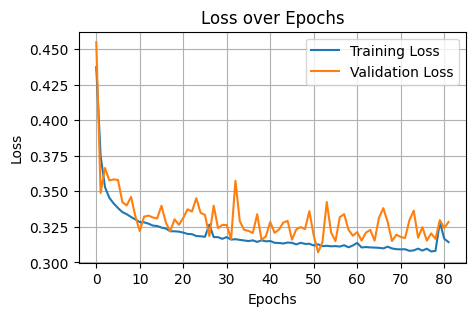

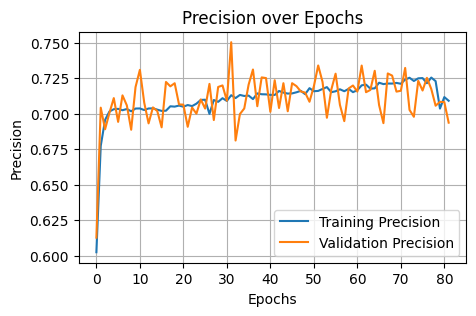

In [17]:
# Plot loss over time
plt.figure(figsize=(5, 3))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot precision over time
plt.figure(figsize=(5, 3))
plt.plot(history.history['precision'], label='Training Precision')
plt.plot(history.history['val_precision'], label='Validation Precision')
plt.title('Precision over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

## Avaliação

434/434 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step


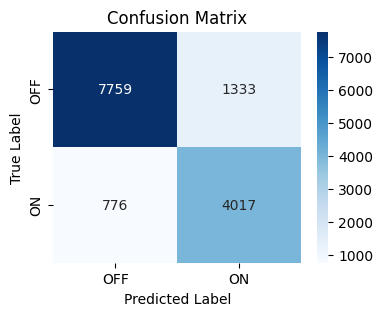

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plot the confusion matrix, using the test subset
y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['OFF', 'ON'], yticklabels=['OFF', 'ON'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

precision = precision_score(y_test, y_pred)
print('Precision:', precision)

recall = recall_score(y_test, y_pred)
print('Recall:', recall)

f1 = f1_score(y_test, y_pred)
print('F1-score:', f1)

Accuracy: 0.8481094706517825
Precision: 0.7508411214953271
Recall: 0.8380972251199666
F1-score: 0.7920733510795622
